## KNN

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


In [3]:
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/teleCust1000t.csv')
df.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   region   1000 non-null   int64  
 1   tenure   1000 non-null   int64  
 2   age      1000 non-null   int64  
 3   marital  1000 non-null   int64  
 4   address  1000 non-null   int64  
 5   income   1000 non-null   float64
 6   ed       1000 non-null   int64  
 7   employ   1000 non-null   int64  
 8   retire   1000 non-null   float64
 9   gender   1000 non-null   int64  
 10  reside   1000 non-null   int64  
 11  custcat  1000 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 93.9 KB


In [5]:
df['custcat'].value_counts()

custcat
3    281
1    266
4    236
2    217
Name: count, dtype: int64

1 = Basic Service, 2 = E-service, 3 = Plus Service, 4 = Total Service

In [12]:
correlation = df.corr()
abs(correlation['custcat'].sort_values())

region     0.023771
gender     0.004966
retire     0.008908
age        0.056909
address    0.067913
reside     0.082022
marital    0.083836
employ     0.110011
income     0.134525
tenure     0.166691
ed         0.193864
custcat    1.000000
Name: custcat, dtype: float64

<Axes: >

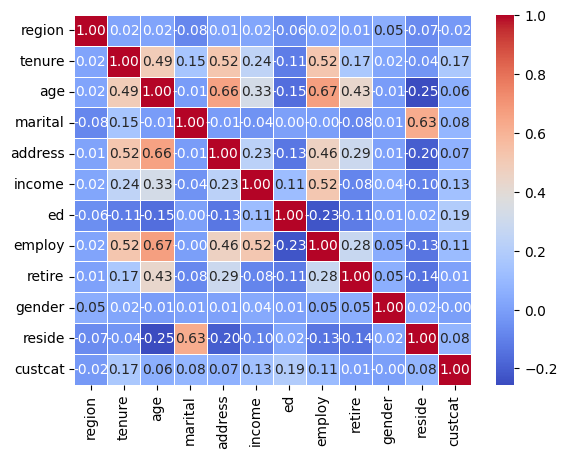

In [11]:
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f',linewidths=0.5)

In [ ]:
target = df['custcat']
features = df.drop('custcat',axis=1)
features

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside
0,2,13,44,1,9,64.0,4,5,0.0,0,2
1,3,11,33,1,7,136.0,5,5,0.0,0,6
2,3,68,52,1,24,116.0,1,29,0.0,1,2
3,2,33,33,0,12,33.0,2,0,0.0,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4
...,...,...,...,...,...,...,...,...,...,...,...
995,3,10,39,0,0,27.0,3,0,0.0,1,3
996,1,7,34,0,2,22.0,5,5,0.0,1,1
997,3,67,59,0,40,944.0,5,33,0.0,1,1
998,3,70,49,0,18,87.0,2,22,0.0,1,1


Data Normalization is important for KNN

In [16]:
features = StandardScaler().fit_transform(features)
features = pd.DataFrame(features)
features

,0,1,2,3,4,5,6,7,8,9,10
0,-0.026968,-1.055125,0.184505,1.010051,-0.253034,-0.126506,1.087753,-0.594123,-0.222076,-1.034598,-0.230650
1,1.198836,-1.148806,-0.691812,1.010051,-0.451415,0.546450,1.906227,-0.594123,-0.222076,-1.034598,2.556662
2,1.198836,1.521092,0.821826,1.010051,1.234819,0.359517,-1.367671,1.787528,-0.222076,0.966559,-0.230650
3,-0.026968,-0.118319,-0.691812,-0.990050,0.044536,-0.416251,-0.549196,-1.090300,-0.222076,0.966559,-0.927478
4,-0.026968,-0.586722,-0.930808,1.010051,-0.253034,-0.444291,-1.367671,-0.891829,-0.222076,-1.034598,1.163006
...,...,...,...,...,...,...,...,...,...,...,...
995,1.198836,-1.195646,-0.213821,-0.990050,-1.145747,-0.472331,0.269278,-1.090300,-0.222076,0.966559,0.466178
996,-1.252771,-1.336167,-0.612147,-0.990050,-0.947366,-0.519064,1.906227,-0.594123,-0.222076,0.966559,-0.927478
997,1.198836,1.474252,1.379482,-0.990050,2.821863,8.098513,1.906227,2.184470,-0.222076,0.966559,-0.927478
998,1.198836,1.614773,0.582830,-0.990050,0.639678,0.088466,-0.549196,1.092880,-0.222076,0.966559,-0.927478


In [17]:
X_train, X_test, y_train, y_test = train_test_split(features,target,test_size=0.3,random_state=42)

In [26]:
k=6
classifier = KNeighborsClassifier(n_neighbors=k)
model = classifier.fit(X_train, y_train)

In [28]:
y_pred = model.predict(X_test)
y_pred

array([4, 2, 3, 3, 3, 3, 4, 3, 1, 1, 2, 2, 4, 3, 1, 1, 4, 4, 1, 4, 1, 1,
       1, 3, 3, 3, 2, 4, 2, 4, 1, 4, 3, 1, 2, 2, 1, 1, 1, 4, 3, 1, 3, 3,
       1, 3, 1, 3, 1, 2, 1, 2, 1, 1, 3, 1, 3, 1, 1, 1, 1, 2, 1, 2, 1, 2,
       1, 1, 1, 1, 3, 3, 3, 3, 2, 1, 3, 3, 3, 1, 4, 1, 2, 3, 1, 3, 1, 4,
       2, 2, 4, 2, 2, 1, 3, 2, 2, 1, 4, 1, 1, 3, 1, 2, 2, 4, 1, 3, 1, 2,
       4, 1, 1, 3, 1, 1, 3, 3, 2, 3, 3, 2, 2, 3, 4, 2, 3, 2, 1, 1, 1, 2,
       1, 1, 2, 2, 1, 2, 1, 1, 4, 2, 1, 4, 1, 4, 2, 3, 3, 3, 1, 4, 3, 3,
       3, 1, 1, 3, 3, 1, 1, 1, 2, 1, 1, 1, 2, 3, 1, 4, 1, 3, 4, 3, 1, 4,
       4, 1, 3, 3, 1, 3, 4, 1, 1, 4, 2, 2, 3, 1, 1, 1, 1, 2, 4, 1, 1, 2,
       4, 3, 1, 1, 3, 1, 4, 1, 3, 3, 4, 3, 1, 3, 4, 3, 3, 3, 3, 4, 4, 3,
       2, 1, 3, 1, 1, 2, 2, 4, 3, 3, 3, 2, 2, 1, 2, 2, 1, 2, 1, 3, 3, 4,
       1, 3, 2, 3, 3, 1, 4, 1, 3, 3, 2, 2, 2, 4, 2, 2, 2, 2, 1, 2, 2, 3,
       1, 1, 4, 3, 1, 1, 1, 3, 2, 1, 2, 3, 1, 3, 1, 4, 1, 1, 2, 1, 4, 2,
       4, 3, 1, 1, 2, 1, 1, 3, 2, 2, 4, 4, 1, 1])

In [29]:
print("Test set Accuracy: ", accuracy_score(y_test, y_pred))

Test set Accuracy:  0.3566666666666667


Finding Optimal K

In [33]:
Ks = 15
acc = np.zeros((Ks))
std_acc = np.zeros((Ks))
for n in range(1,Ks+1):
    #Train Model and Predict  
    knn_model_n = KNeighborsClassifier(n_neighbors = n).fit(X_train,y_train)
    yhat = knn_model_n.predict(X_test)
    acc[n-1] = accuracy_score(y_test, yhat)
    std_acc[n-1] = np.std(yhat==y_test)/np.sqrt(yhat.shape[0])

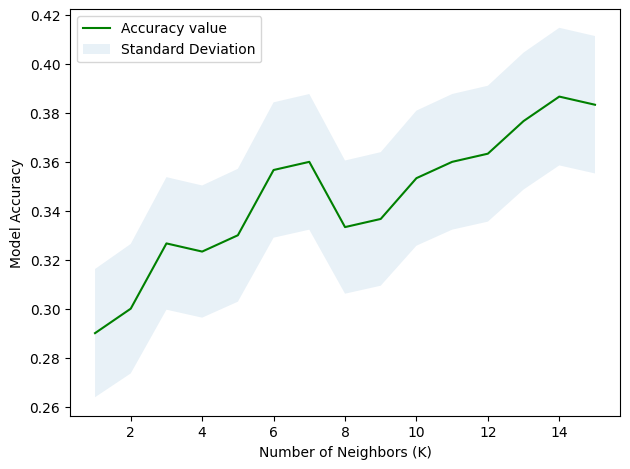

In [34]:
plt.plot(range(1,Ks+1),acc,'g')
plt.fill_between(range(1,Ks+1),acc - 1 * std_acc,acc + 1 * std_acc, alpha=0.10)
plt.legend(('Accuracy value', 'Standard Deviation'))
plt.ylabel('Model Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.tight_layout()
plt.show()

In [35]:
print( "The best accuracy was with", acc.max(), "with k =", acc.argmax()+1) 

The best accuracy was with 0.38666666666666666 with k = 14
